In questo esercizio si genera una distribuzione casuale di punti (come un universo finto senza clustering) e si calcola lo spettro di potenza P(k) a partire dalla trasformata di Fourier del campo di densità su una griglia 3D.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfftn,fftfreq,rfftfreq  

In [22]:
L=1000 # Box size in mpc/h
volume=L**3
n_points=100000 # Numero di particelle
density=n_points/volume
print("Density: ",density)

# Creo le coordinate x, y, z distribuite uniformemente nel box
x,y,z=np.random.uniform(0,L,size=(3,n_points))  

Density:  0.0001


In [23]:
n_cells=64 # Numero di celle per lato, meglio che sia un potenza di 2 
cell_size=L/n_cells  # Lato di ciascuna cella, mpc/h
print("Cell size: ",cell_size) 

cell_mean_density=n_points/n_cells**3   # Densità media per cella, mpc**-3/h**3
print("Mean density in the cell: ",cell_mean_density) 

# Creo una griglia 3D che conta quante particelle ci sono in ogni cella
grid,edges=np.histogramdd((x,y,z),bins=(n_cells,n_cells,n_cells),range=((0,L),(0,L),(0,L)))

# Calcolo il campo di densità come (densità locale - media) / media
density_field=(grid-cell_mean_density)/cell_mean_density 

Cell size:  15.625
Mean density in the cell:  0.3814697265625


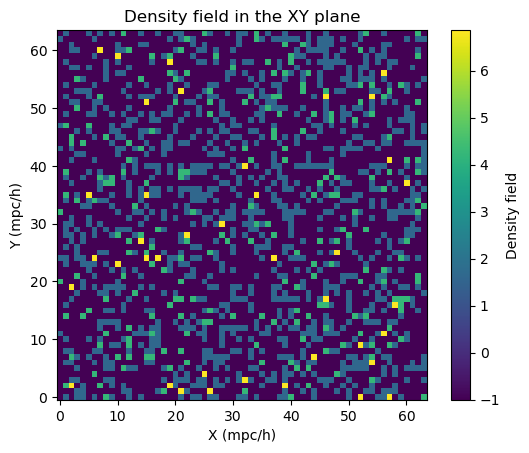

In [24]:
plt.imshow(density_field[:,:,0],origin='lower',cmap='viridis') # Plot 2d del campo di densità sul piano XY con z=0
plt.colorbar(label='Density field')
plt.title('Density field in the XY plane')
plt.xlabel('X (mpc/h)')
plt.ylabel('Y (mpc/h)')
plt.show()

In [25]:
# calcolo la FFT del campo di densità
delta_k=rfftn(density_field)/n_cells**3  

# Definisco le freq fondamnetali
kF=2*np.pi/L  # Freq Fondamentale
H=L/n_cells   
kN=np.pi/H   # Freq. Nyquist
kx=fftfreq(n_cells,d=1/n_cells)*kF  # Griglia dei vettori k per direzione x
ky=fftfreq(n_cells,d=1/n_cells)*kF
kz=rfftfreq(n_cells,d=1/n_cells)*kF

# meshgrid per combinare le tre componenti
KX,KY,KZ=np.meshgrid(kx,ky,kz)  
KK=np.sqrt(KX**2+KY**2+KZ**2)  # Modulo di K


Text(0.5, 1.0, 'Dispersione di P(k) in funzione di k')

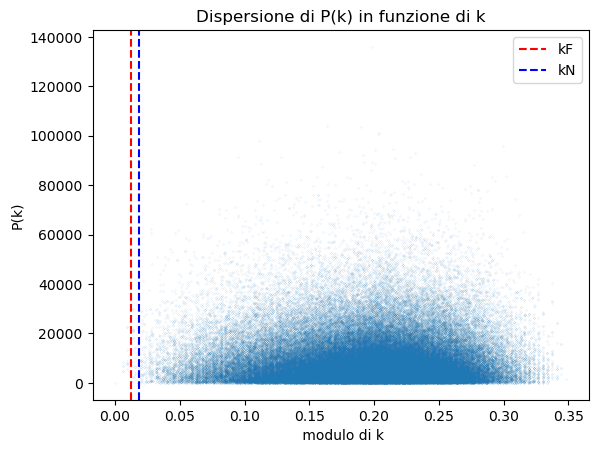

In [26]:
# Calcolo spettro di potenza su griglia
pk_grid=delta_k*np.conjugate(delta_k)*volume  #metto il volume perchè non sono nel continuo ma nel discreto

# Binning
c=1
k_edges=np.arange(kF,kN,c*kF) 
k_bins=0.5*(k_edges[1:]+k_edges[:-1])

# Visualizzo distribuzione dei punti pk(k)
plt.plot(KK.flatten(), pk_grid.flatten(), '.', markersize=0.1)
plt.axvline(k_edges[1], color='red', linestyle='--', label='kF')
plt.axvline(k_edges[2], color='blue', linestyle='--', label='kN')
plt.xlabel(" modulo di k")
plt.ylabel("P(k)")
plt.legend()
plt.title("Dispersione di P(k) in funzione di k")

/tmp/ipykernel_159832/2419399028.py:7: ComplexWarning: Casting complex values to real discards the imaginary part
  pk_averaged[i]=np.mean(pk_grid.flatten()[mask]) # spettro di potenza medio in ciascun guscio


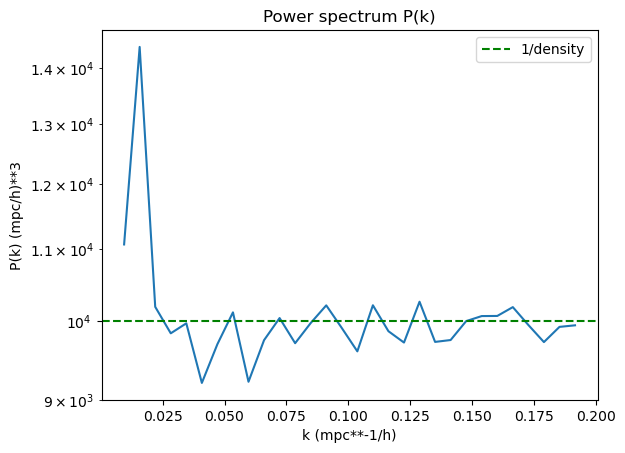

In [27]:
# Faccio il binning per mediare P(k) su anelli sferici nello spazio di Fouerier
pk_averaged=np.zeros(k_bins.shape) 
k_averaged=np.zeros(k_bins.shape)

for i in range(len(k_bins)): # per ogni anello
    mask=(KK.flatten()>=k_edges[i]) & (KK.flatten()<k_edges[i+1]) # seleziona tutti i punti il cui modulo k ricade nel bin corrente
    pk_averaged[i]=np.mean(pk_grid.flatten()[mask]) # spettro di potenza medio in ciascun guscio
    k_averaged[i]=np.mean(KK.flatten()[mask]) # centri effettivi dei bin

# Visualizzo la media di P(k) su anelli sferici
plt.semilogy(k_bins,pk_averaged,'-',markersize=5)
plt.axhline(1./density, color='green', linestyle='--', label='1/density')  # Shot Noise atteso
plt.xlabel('k (mpc**-1/h)')
plt.ylabel('P(k) (mpc/h)**3')
plt.title('Power spectrum P(k)')
plt.legend()
plt.show()
    

NB: L’andamento di P(k) è piatto e oscilla intorno a un valore costante: questo è il comportamento atteso per un universo random, ovvero nessuna struttura, nessuna scala preferita. Lo shot noise è causato dal fatto che le particelle sono discrete.Il fatto che P(k) oscilli proprio intorno allo shot noise conferma che  i punti siano davvero distribuiti in modo casuale.

NB: Per ottenere uno spettro di potenza P(k) che abbia senso fisico, dobbiamo mediare i valori di |delta(k_vettore)| che hanno lo stesso modulo k=|k_vettore|, cioè che si trovano alla stessa distanza dall’origine nello spazio di Fourier. Questo perché in cosmologia si assume che l’universo sia isotropo, quindi P(k) non deve dipendere dalla direzione. Inoltre, fare la media su tanti punti aiuta a ridurre il rumore e rende il risultato confrontabile con le previsioni teoriche, che forniscono proprio (k) come funzione della scala.